In [1]:
import librosa
import matplotlib.pyplot as plt
import librosa.display
import torchaudio
import torch

In [2]:
y, sr = librosa.load("test_great_balls_of_fire.mp3", sr=44100, mono=True)

In [5]:
y.shape

(5107968,)

In [6]:
y

array([0.000000e+00, 8.798518e-12, 9.348676e-12, ..., 0.000000e+00,
       0.000000e+00, 0.000000e+00], dtype=float32)

In [7]:
sr

44100

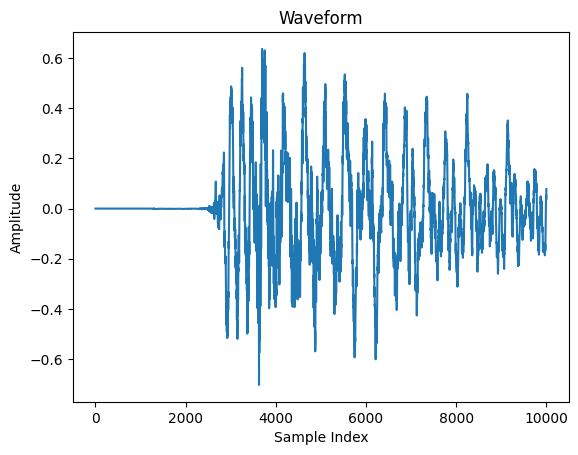

In [3]:

plt.plot(y[:10000])  # Plot the first 1000 samples
plt.title("Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

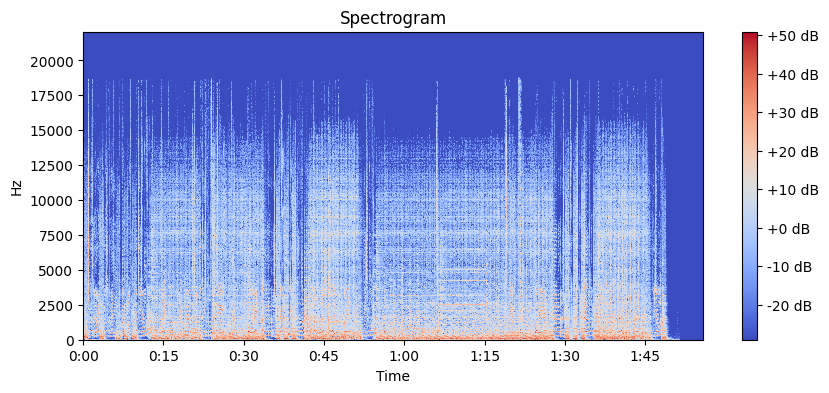

In [4]:
D = librosa.stft(y)  # Short-time Fourier transform
S_db = librosa.amplitude_to_db(abs(D))

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

In [2]:
from musedbdataset import SourceSeparationDataset

In [3]:
path = r"F:\musdb18hq"

In [4]:
dataset = SourceSeparationDataset(path, "train", patch_length=20, stride_frames=5)

In [5]:
wave_seg = dataset[5]["wave_segments"]

In [6]:
spec_patches = dataset[5]["spec_patches"]

In [7]:
from utils import visualize_wave_spec_pair

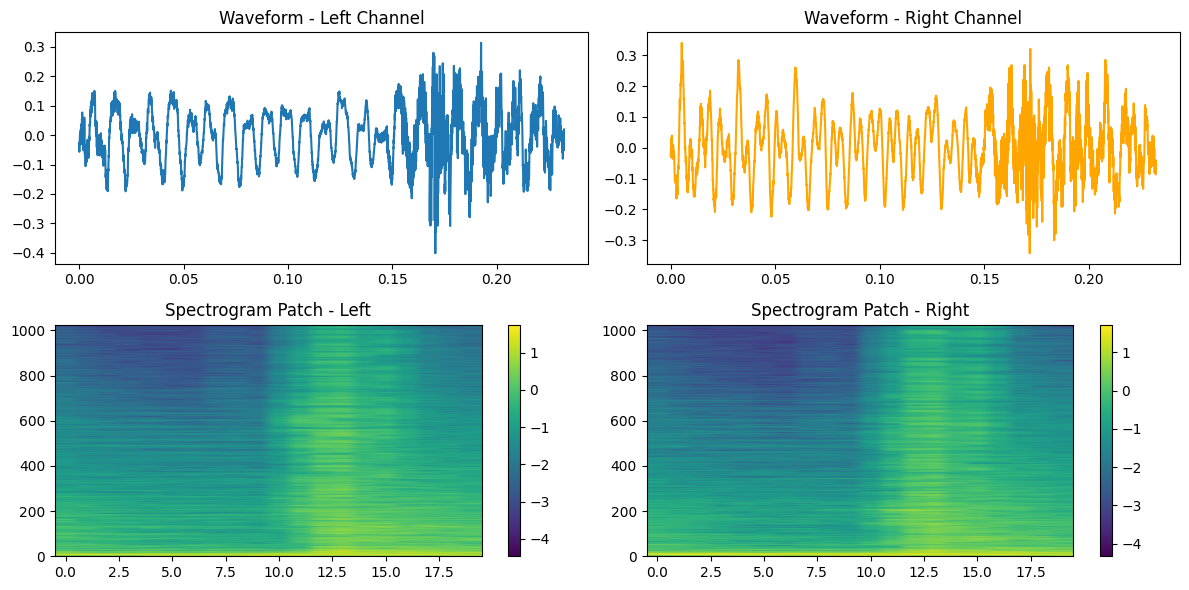

In [8]:
visualize_wave_spec_pair(wave_seg, spec_patches, index=1002)

In [9]:
wave_seg.shape

torch.Size([7211, 2, 10240])

In [5]:
from models import WaveEncoder

In [19]:
wave_encoder = WaveEncoder()

In [12]:
wave_seg_b = wave_seg.unsqueeze(dim=0)

In [13]:
out = wave_encoder(wave_seg)

In [14]:
out.shape

torch.Size([7211, 256])

In [15]:
new_ot = out.view(1, 7211, -1)

In [16]:
new_ot.shape

torch.Size([1, 7211, 256])

In [6]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

In [7]:
def collate_fn(batch):
    """
    Pads variable-length wave/spec sequences across batch.
    Each item in batch is a dict from your Dataset's __getitem__
    """
    wave_list = [item['wave_segments'] for item in batch]   # [N_i, 2, segment_samples]
    spec_list = [item['spec_patches'] for item in batch]    # [N_i, 2, F, patch_length]

    wave_lens = [seg.shape[0] for seg in wave_list]
    spec_lens = [seg.shape[0] for seg in spec_list]
    assert wave_lens == spec_lens, "Mismatch between wave/spec segment counts"

    # Pad sequences along N (time dimension)
    wave_padded = pad_sequence(wave_list, batch_first=True)  # [B, max_N, 2, segment_samples]
    spec_padded = pad_sequence(spec_list, batch_first=True)  # [B, max_N, 2, F, patch_length]

    # Create a segment mask: 1 where valid, 0 where padded
    max_len = max(wave_lens)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    for i, l in enumerate(wave_lens):
        mask[i, :l] = 1

    return {
        'wave_segments': wave_padded,   # [B, max_N, 2, segment_samples]
        'spec_patches':  spec_padded,   # [B, max_N, 2, F, patch_length]
        'segment_mask':  mask,          # [B, max_N]
        'song_names':    [item['song_name'] for item in batch]
    }

In [8]:
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

In [12]:
batch = next(iter(dataloader))

In [13]:
batch["wave_segments"].shape

torch.Size([2, 5589, 2, 10240])

In [14]:
batch["spec_patches"].shape

torch.Size([2, 5589, 2, 1025, 20])

In [15]:
batch_wave = batch["wave_segments"]
B, N, C, T = batch_wave.shape

In [16]:
N

5589

In [17]:
gpu_data = batch_wave.view(B * N, C, T).to("cuda")

In [20]:
gpu_encoder = wave_encoder.to("cuda")

In [ ]:
out = gpu_encoder(gpu_data)